## Analysis of Screen Time, Sleep, and Productivity

In [19]:
from google.colab import files
uploaded = files.upload()

Saving archive (3).zip to archive (3) (3).zip


In [20]:
import pandas as pd

# Get the uploaded file name automatically
file_name = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(file_name)

df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


In [21]:
df.columns = df.columns.str.strip()
numeric_df = df.select_dtypes(include=['number'])

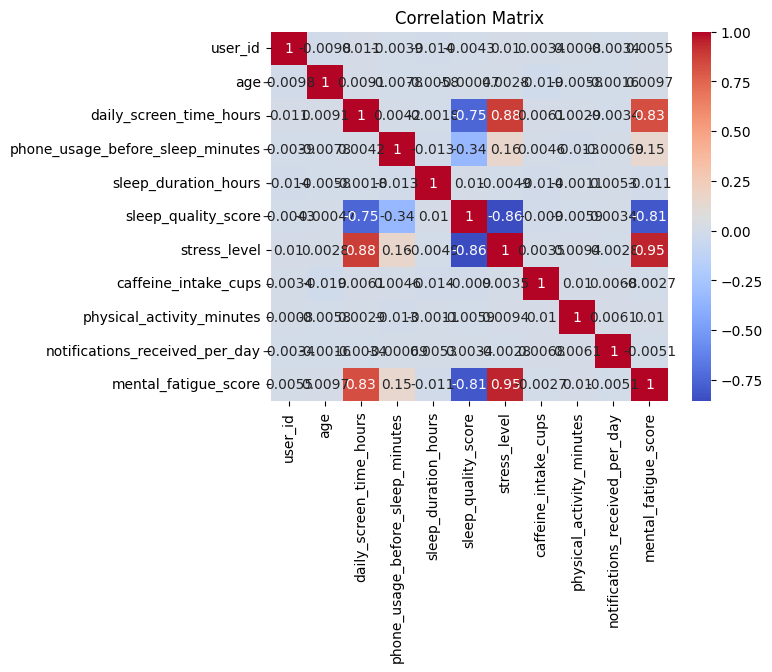

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

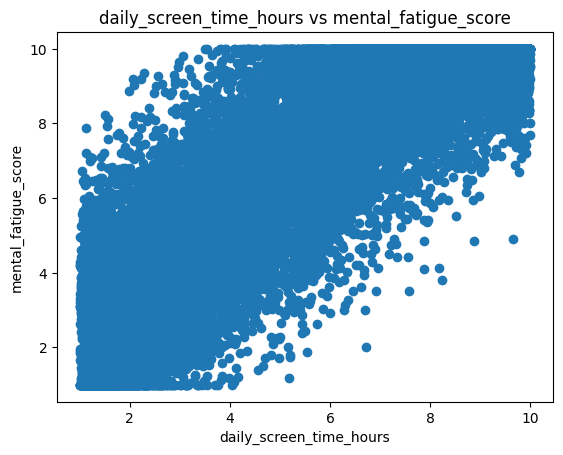

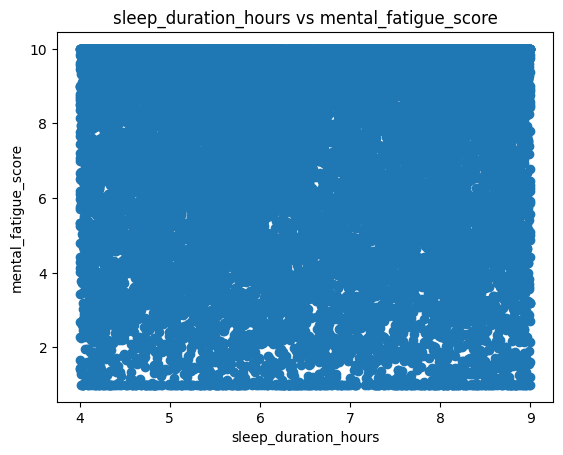

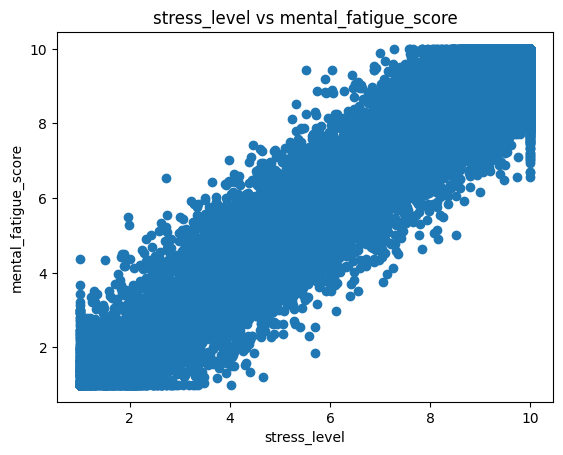

In [23]:
cols = ['daily_screen_time_hours', 'sleep_duration_hours', 'stress_level']
y = 'mental_fatigue_score'

for col in cols:
    plt.scatter(df[col], df[y])
    plt.xlabel(col)
    plt.ylabel(y)
    plt.title(f"{col} vs {y}")
    plt.show()

In [24]:
from sklearn.linear_model import LinearRegression

X = df[['daily_screen_time_hours', 'sleep_duration_hours', 'stress_level']]
y = df['mental_fatigue_score']

model = LinearRegression()
model.fit(X, y)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [-0.02579322 -0.01197398  0.96365568]
Intercept: 0.3663033122195527
